The purpose of this notebook is to develop functions that will convert the ARF and the RMF from .npz arrays into the standard OGIP format such that they can be used with 3ML.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
from pathlib import Path
import os

import astropy.units as u
from astropy.table import Table
from astropy.time import Time
from astropy.modeling import models, fitting
from astropy.visualization import quantity_support
from astropy.io import fits
from pathlib import Path

from specutils import Spectrum1D, analysis

from specutils import SpectralRegion
from specutils.manipulation import extract_region
from specutils.fitting import fit_lines

quantity_support()
import specutils
specutils.conf.do_continuum_function_check = False
%load_ext autoreload
%autoreload 2

In [2]:
data_dir = Path(r"C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis/data/")

Goal: develop a function that takes an ARF matrix and outputs an ARF fits file.

In [3]:
# read in the ARF
arf = np.load(data_dir / "MeDDEA_ARF_1.0.npz")

In [4]:
np.shape(arf)
arf.keys()

KeysView(NpzFile 'C:\\Users\\ngodbole\\OneDrive - NASA\\Desktop\\analysis\\data\\MeDDEA_ARF_1.0.npz' with keys: arf, True_E_center)

The ARF is a 2D array of effective area (cm2) and true energies. 

In [5]:
np.shape(arf['arf'])

(1500,)

The ARF has 1500 energy bins.

This ARF was calculated from a simulation in which a 1cm x 1cm source (placed at infinity) was used to illuminate the face of a single 1cm x 1cm detector. In reality, this is unphysical, as the source region will illuminate more than just 1 detector. Incident photons hitting the collimator or the Tungsten frame will generate secondary photons, which will contribute to the background. THe effect will be more pronounced with higher solar flux. 

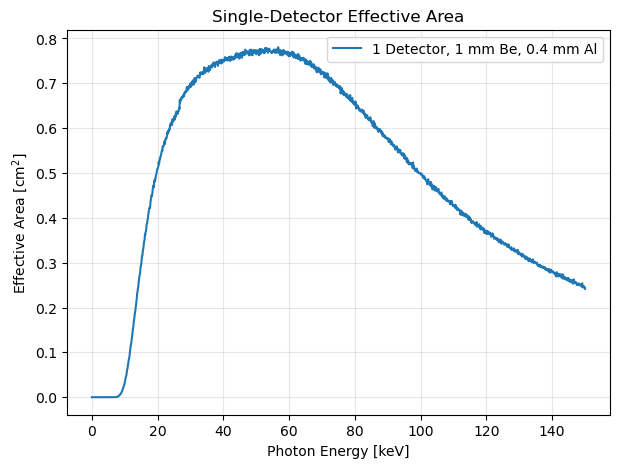

In [6]:
# Plot the ARF
fig, ax = plt.subplots(1, 1, figsize=(7,5))
ax.plot(arf['True_E_center'], arf['arf'], label='1 Detector, 1 mm Be, 0.4 mm Al')
ax.set_xlabel('Photon Energy [keV]')
ax.set_ylabel(r'Effective Area [cm$^{2}$]')
ax.set_title("Single-Detector Effective Area")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The effective area for the full detector system is 4 times the effective area for a single detector. How does this compare with MeDDEA's requirements? 

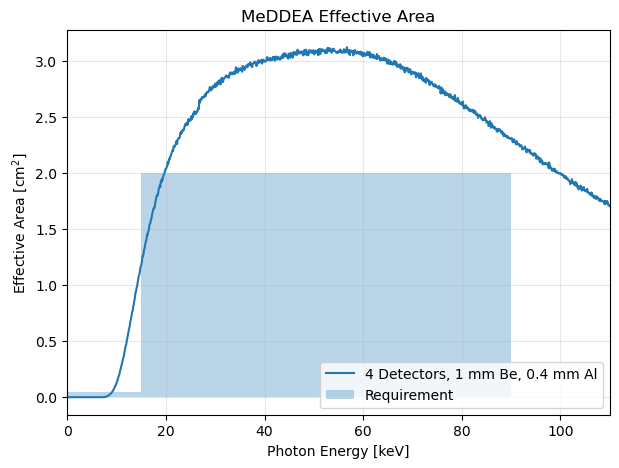

In [7]:
# The effective area must be >= 2 cm2 from 15 to 90 keV and >= 0.05 cm2 from 5 to 15 keV. 
# This version of the ARF is for a single detector only.

# Plot the ARF
fig, ax = plt.subplots(1, 1, figsize=(7,5))
ax.plot(arf['True_E_center'], 4*arf['arf'], label='4 Detectors, 1 mm Be, 0.4 mm Al')
ax.set_xlabel('Photon Energy [keV]')
ax.set_ylabel(r'Effective Area [cm$^{2}$]')

# Box 1: x from 5-15 (effective area units), y from 0-0.05 keV
box1 = patches.Rectangle((0, 0), 15, 0.05, 
                        linewidth=2, alpha=0.3)

# Box 2: x from 15-90 keV, y from 0-2 (effective area units)
box2 = patches.Rectangle((15, 0), 75, 2, 
                        linewidth=2, alpha=0.3, label='Requirement')

# Add the patches to the axes
ax.add_patch(box1)
ax.add_patch(box2)

plt.title("MeDDEA Effective Area")
plt.xlim(0,110)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

From: https://heasarc.gsfc.nasa.gov/docs/heasarc/caldb/docs/memos/cal_gen_92_002/cal_gen_92_002.html

4.1.1  Extension Header \
The header must include the following (mandatory) keywords: \
EXTNAME (= 'SPECRESP') - the name (ie type) of the extension \
TELESCOP - the "telescope" (ie mission/satellite name). \
INSTRUME - the instrument/detector. \
FILTER - the instrument filter in use (if any) \
HDUCLASS = 'OGIP' - file format is OGIP standard. \
HDUCLAS1 = 'RESPONSE' - extension contains response data. \
HDUCLAS2 = 'SPECRESP' - extension contains an ARF. \
HDUVERS = '1.1.0' - version of the file format. 

The following optional keywords supply further information: \
PHAFILE - name of PHA file for which this file was produced. 

The general HEASARC standard for ARFs also makes use of the BINTABLE FITS format, and thus the data again resides in a single extension of a FITS file (though generally as a file separate from the RMF) with a null primary array.

In [8]:
# Sanity check: 
# What energies correspond to the centers of the energy bins?
# What is the width of the energy bins? Note that the energy bins are uniformly spaced.
energy_centers = arf['True_E_center']
energy_width = np.diff(energy_centers)[0]

print('The centers of the energy bins: ' + str(energy_centers) + ' keV')
print('The width of the energy bins: ' + str(energy_width) + ' keV')

The centers of the energy bins: [5.00000000e-02 1.50066711e-01 2.50133422e-01 ... 1.49849867e+02
 1.49949933e+02 1.50050000e+02] keV
The width of the energy bins: 0.1000667111407605 keV


# ARF
Goal: create a function that will translate a given ARF file (.npz) into a .fits file in the OGIP format. 

In [9]:
def convert_arf_to_fits(arf_file, plot_comparison): 
    """
    This function takes an ARF file (.npz) as input, and outputs an ARF (.fits) file in the OGIP format.
    The ouput file should include a Header, a null Primary array, and a Bintable secondary array containing the ARF.
    
    Inputs 
        arf_file: input arf file (.npz) format
            
    Outputs
        arf_fits_file: output arf file (.fits) format
    """

    # Split the filename and the extension. 
    filename, extension = os.path.splitext(arf_file)

    # Create the Primary HDU. 
    # The primary HDU should be null. 
    primary_hdu = fits.PrimaryHDU()
    
    # Create the Secondary HDU. 
    # The secondary HDU whould contain the ARF. 
    arf = np.load(arf_file)
    energy_centers = arf['True_E_center']
    effective_area = arf['arf']

    # Convert energy_centers to arrays of upper and lower energy bounds (energ_lo and energy_hi). 
    # Olivier confirmed that the energy bins are uniformly spaced. 
    energy_width = np.diff(energy_centers)[0]
    energ_lo = energy_centers - energy_width/2. # Low energy bounds for each energy bin.
    energ_hi = energy_centers + energy_width/2. # High energy bounds for each energy bin.

    arf_hdu = fits.BinTableHDU.from_columns([
        fits.Column(name='ENERG_LO', format='E', array=energ_lo, unit='keV'),
        fits.Column(name='ENERG_HI', format='E', array=energ_hi, unit='keV'),
        fits.Column(name='SPECRESP', format='E', array=effective_area, unit='cm**2')
    ])

    # Create the header. 
    # Define the Header fields and associated values and comments in a dictionary.
    fields = {'XTENSION':('BINTABLE', 'binary table extension'),
              'EXTNAME':('SPECRESP', 'name of this binary table extension'),
              'TELESCOP':'PADRE',
              'INSTRUME':'MEDDEA',
              #'DETNAM':ASIC ???,
              'FILTER':'MLI, BE, AL',
              'HDUCLASS':'OGIP',
              'HDUCLAS1':'RESPONSE',
              'HDUCLAS2':'SPECRESP',
              'HDUVERS':'1.1.0', #TODO: verify the correct version number to use.
              #'PHAFILE': #TODO: optional keyword; include the name of the PHA file for which the ARF was produced.
              'ARFVERSN':('1992a', 'Obsolete; included for backwards compatibility.'),
              'HDUVERS1':('1.0.0', 'Obsolete; included for backwards compatibility.'),
              'HDUVERS2':('1.1.0', 'Obsolete; included for backwards compatibility.')
              }
    
    for this_field, this_value in zip(fields.keys(), fields.values()): 
        #print(this_field, this_value)
        arf_hdu.header[this_field] = this_value

    # Write the FITS file. 
    hdul = fits.HDUList([primary_hdu, arf_hdu])
    hdul.writeto(f'{filename}.arf', overwrite=True) # generate the output .fits file.

    if plot_comparison == True: 
        fig, (ax1) = plt.subplots(1, 1, figsize=(7, 5))

        ax1.plot(arf['True_E_center'], arf['arf'], label = 'Unconverted')
        ax1.plot(arf_hdu.data['ENERG_HI'] - energy_width/2., arf_hdu.data['SPECRESP'], label = 'Converted')
        
        ax1.set_xlabel('Measured Energy [keV]')
        ax1.set_ylabel('Photon Energy [keV]')
        ax1.set_title("ARF (Single Detector Configuration, Single Events Only)")
        ax1.legend()

        plt.savefig('ARF_Comparison.png', dpi=150)
        plt.show()
    return hdul

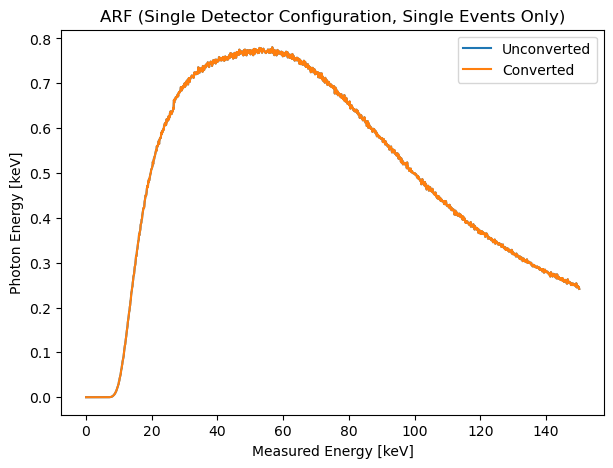

In [10]:
# Test that the conversion worked. 
arf_converted = convert_arf_to_fits(data_dir / "MeDDEA_ARF_1.0.npz", plot_comparison=True)

The converted data appears to match the original data! 

In [11]:
arf_converted[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  

In [12]:
print(arf_converted[0].data)

None


The primary array is null, as expected.

In [13]:
arf_converted[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   12 / length of dimension 1                          
NAXIS2  =                 1500 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    3 / number of table fields                         
TTYPE1  = 'ENERG_LO'                                                            
TFORM1  = 'E       '                                                            
TUNIT1  = 'keV     '                                                            
TTYPE2  = 'ENERG_HI'                                                            
TFORM2  = 'E       '        

In [14]:
arf_converted[1].data

FITS_rec([(-3.3355569e-05, 1.0003336e-01, 0.     ),
          ( 1.0003336e-01, 2.0010006e-01, 0.     ),
          ( 2.0010006e-01, 3.0016679e-01, 0.     ), ...,
          ( 1.4979984e+02, 1.4989990e+02, 0.24375),
          ( 1.4989990e+02, 1.4999997e+02, 0.24504),
          ( 1.4999997e+02, 1.5010004e+02, 0.2415 )],
         shape=(1500,), dtype=(numpy.record, [('ENERG_LO', '<f4'), ('ENERG_HI', '<f4'), ('SPECRESP', '<f4')]))

In [15]:
arf_converted[1].data.columns

ColDefs(
    name = 'ENERG_LO'; format = 'E'; unit = 'keV'
    name = 'ENERG_HI'; format = 'E'; unit = 'keV'
    name = 'SPECRESP'; format = 'E'; unit = 'cm**2'
)

In [16]:
arf_converted[1].data['ENERG_HI']

array([1.0003336e-01, 2.0010006e-01, 3.0016679e-01, ..., 1.4989990e+02,
       1.4999997e+02, 1.5010004e+02], shape=(1500,), dtype=float32)

In [17]:
arf_converted[1].data['ENERG_LO']

array([-3.3355569e-05,  1.0003336e-01,  2.0010006e-01, ...,
        1.4979984e+02,  1.4989990e+02,  1.4999997e+02],
      shape=(1500,), dtype=float32)

In [18]:
bin_width = (arf_converted[1].data['ENERG_HI'][1:] - arf_converted[1].data['ENERG_LO'][1:])[0]

In [19]:
bin_width

np.float32(0.10006671)

# RMF
Goal: create a function that will translate a given RMF file (.npz) into a .fits file in the OGIP format. 

In [20]:
rmf = np.load(data_dir / "MeDDEA_RMF_1.0.npz")

In [21]:
rmf

NpzFile 'C:\\Users\\ngodbole\\OneDrive - NASA\\Desktop\\analysis\\data\\MeDDEA_RMF_1.0.npz' with keys: rmf, True_E_center, Meas_C_center

In [22]:
np.shape(rmf['rmf'])

(1500, 1500)

In [23]:
type(rmf['True_E_center'][0])

numpy.float64

In [24]:
rmf['Meas_C_center'], rmf['True_E_center']

(array([5.00000000e-02, 1.50066711e-01, 2.50133422e-01, ...,
        1.49849867e+02, 1.49949933e+02, 1.50050000e+02], shape=(1500,)),
 array([5.00000000e-02, 1.50066711e-01, 2.50133422e-01, ...,
        1.49849867e+02, 1.49949933e+02, 1.50050000e+02], shape=(1500,)))

In [27]:
class ResponseFileProcessor:
    """
    A class to handle loading, converting, and validating X-ray response files (RMF/ARF)
    """
    

    def __init__(self, data_dir):
        """
        Initialize the processor with a data directory
        
        Parameters:
        -----------
        data_dir : str or Path
            Directory containing the response files
        """
        self.data_dir = Path(data_dir)
        
    def load_rmf_data(self, rmf_filename):
        """
        Load RMF data from .npz file
        
        Parameters:
        -----------
        rmf_filename : str
            Name of the RMF file (e.g., "MeDDEA_RMF_1.0.npz")
            
        Returns:
        --------
        dict : Dictionary containing RMF data
        """
        rmf_file = self.data_dir / rmf_filename
        return np.load(rmf_file)
    

    def convert_rmf_to_fits(self, rmf_filename, output_filename=None, cif=False, plot_comparison=True):
        """
        Convert RMF from .npz to FITS format following OGIP standard
        Creates properly formatted variable-length arrays from the start
        
        Parameters:
        -----------
        rmf_filename : str
            Input RMF filename
        output_filename : str, optional
            Output filename (if None, uses input name with .rmf extension)
        cif : bool, optional
            Whether to include CIF entries in headers
        plot_comparison : bool, optional
            Whether to create comparison plots
            
        Returns:
        --------
        fits.HDUList : The converted RMF
        """
        rmf_file = self.data_dir / rmf_filename
        
        # Determine output filename
        if output_filename is None:
            filename = os.path.splitext(rmf_file)[0]
            output_file = f'{filename}.rmf'
        else:
            output_file = self.data_dir / output_filename
        
        # Create Primary HDU
        primary_hdu = fits.PrimaryHDU()
        
        # Load RMF data
        rmf_data = np.load(rmf_file)
        response_matrix = rmf_data['rmf']
        true_energy_centers = rmf_data['True_E_center']
        measured_energy_centers = rmf_data['Meas_C_center']
        
        # Convert energy centers to bounds
        true_energy_width = np.median(np.diff(true_energy_centers))
        true_energy_lo = true_energy_centers - true_energy_width/2.
        true_energy_hi = true_energy_centers + true_energy_width/2.
        
        measured_energy_width = np.median(np.diff(measured_energy_centers))
        measured_energy_lo = measured_energy_centers - measured_energy_width/2.
        measured_energy_hi = measured_energy_centers + measured_energy_width/2.
        
        # Compress matrix with proper OGIP formatting
        compressed_data = self._compress_response_matrix(response_matrix)
        
        # Create MATRIX HDU with proper variable-length arrays
        matrix_hdu = self._create_matrix_hdu(
            true_energy_lo, true_energy_hi, compressed_data, len(measured_energy_centers)
        )
        
        # Create EBOUNDS HDU
        ebounds_hdu = self._create_ebounds_hdu(
            measured_energy_lo, measured_energy_hi
        )
        
        # Create HDU list and write to file
        rmf_converted = fits.HDUList([primary_hdu, matrix_hdu, ebounds_hdu])
        rmf_converted.writeto(output_file, overwrite=True)
        print(f"RMF file written to {output_file}")
        
        # Print compression statistics
        self._print_compression_stats(response_matrix, compressed_data['matrix_flat'])
        
        # Plot comparison if requested
        if plot_comparison:
            self._plot_rmf_comparison(
                response_matrix, true_energy_centers, measured_energy_centers,
                compressed_data
            )
        
        return rmf_converted
    

    def _compress_response_matrix(self, response_matrix):
        """
        Compress response matrix using OGIP standard format
        Creates properly formatted variable-length arrays from the start
        
        Parameters:
        -----------
        response_matrix : np.ndarray
            2D response matrix
            
        Returns:
        --------
        dict : Compressed matrix data with proper OGIP formatting
        """
        n_energies, n_channels = response_matrix.shape
        
        # Initialize storage arrays
        n_grp_list = []
        f_chan_vla_list = []
        n_chan_vla_list = []
        matrix_vla_list = []
        
        # For statistics
        f_chan_flat = []
        n_chan_flat = []
        matrix_flat = []
        
        # Process each energy row
        for i in range(n_energies):
            row = response_matrix[i]
            nonzero_indices = np.where(row > 0)[0]
            
            if len(nonzero_indices) == 0:
                # No response in this energy bin - create empty arrays
                n_grp_list.append(0)
                f_chan_vla_list.append(np.array([], dtype=np.int32))
                n_chan_vla_list.append(np.array([], dtype=np.int32))
                matrix_vla_list.append(np.array([], dtype=np.float32))
                continue
            
            # Identify contiguous groups
            groups = self._find_contiguous_groups(nonzero_indices)
            n_grp_list.append(len(groups))
            
            # Process groups for this energy - create proper arrays
            f_chan_this_energy = np.zeros(len(groups), dtype=np.int32)
            n_chan_this_energy = np.zeros(len(groups), dtype=np.int32)
            matrix_this_energy = []
            
            for g, (start_chan, n_chan) in enumerate(groups):
                f_chan_this_energy[g] = start_chan
                n_chan_this_energy[g] = n_chan
                matrix_this_energy.extend(row[start_chan:start_chan+n_chan])
                
                # For flat arrays (statistics)
                f_chan_flat.append(start_chan)
                n_chan_flat.append(n_chan)
                matrix_flat.extend(row[start_chan:start_chan+n_chan])
            
            # Store as properly sized numpy arrays
            f_chan_vla_list.append(f_chan_this_energy)
            n_chan_vla_list.append(n_chan_this_energy)
            matrix_vla_list.append(np.array(matrix_this_energy, dtype=np.float32))
        
        # Calculate dimensions for OGIP format
        max_grp = max(n_grp_list) if n_grp_list else 1
        max_matrix_elements = max([len(arr) for arr in matrix_vla_list]) if matrix_vla_list else 1
        
        return {
            'n_grp_array': np.array(n_grp_list, dtype=np.int32),
            'f_chan_vla_list': f_chan_vla_list,
            'n_chan_vla_list': n_chan_vla_list,
            'matrix_vla_list': matrix_vla_list,
            'f_chan_flat': np.array(f_chan_flat, dtype=np.int32),
            'n_chan_flat': np.array(n_chan_flat, dtype=np.int32),
            'matrix_flat': np.array(matrix_flat, dtype=np.float32),
            'max_grp': max_grp,
            'max_matrix_elements': max_matrix_elements
        }
    

    def _find_contiguous_groups(self, indices):
        """Find contiguous groups in array indices"""
        if len(indices) == 0:
            return []
        
        groups = []
        start_idx = indices[0]
        current_len = 1
        
        for j in range(1, len(indices)):
            if indices[j] == indices[j-1] + 1:
                current_len += 1
            else:
                groups.append((start_idx, current_len))
                start_idx = indices[j]
                current_len = 1
        
        groups.append((start_idx, current_len))
        return groups
    

    def _create_matrix_hdu(self, true_energy_lo, true_energy_hi, compressed_data, n_channels):
        """
        Create MATRIX HDU with proper OGIP-compliant variable-length arrays
        
        Parameters:
        -----------
        true_energy_lo : array
            Lower true energy bounds
        true_energy_hi : array
            Upper true energy bounds
        compressed_data : dict
            Compressed matrix data
        n_channels : int
            Number of measured energy channels
        """
        
        # Create columns with proper variable-length array formatting
        matrix_cols = [
            fits.Column(name='ENERG_LO', format='D', array=true_energy_lo, unit='keV'),
            fits.Column(name='ENERG_HI', format='D', array=true_energy_hi, unit='keV'),
            fits.Column(name='N_GRP', format='I', array=compressed_data['n_grp_array']),
        ]
        
        # Handle F_CHAN and N_CHAN as proper variable-length arrays
        # The key is to ensure these are properly formatted from the start
        max_grp = compressed_data['max_grp']
        
        if max_grp > 0:
            # Create proper variable-length array columns
            # Format: PJ(max_elements) for integers, PE(max_elements) for floats
            f_chan_col = fits.Column(
                name='F_CHAN', 
                format=f'PJ({max_grp})', 
                array=compressed_data['f_chan_vla_list']
            )
            n_chan_col = fits.Column(
                name='N_CHAN', 
                format=f'PJ({max_grp})', 
                array=compressed_data['n_chan_vla_list']
            )
            matrix_col = fits.Column(
                name='MATRIX', 
                format=f'PE({compressed_data["max_matrix_elements"]})', 
                array=compressed_data['matrix_vla_list']
            )
        else:
            # Handle edge case where there are no groups
            empty_arrays = [np.array([], dtype=np.int32) for _ in range(len(true_energy_lo))]
            f_chan_col = fits.Column(name='F_CHAN', format='PJ(1)', array=empty_arrays)
            n_chan_col = fits.Column(name='N_CHAN', format='PJ(1)', array=empty_arrays)
            matrix_col = fits.Column(name='MATRIX', format='PE(1)', 
                                   array=[np.array([], dtype=np.float32) for _ in range(len(true_energy_lo))])
        
        matrix_cols.extend([f_chan_col, n_chan_col, matrix_col])
        
        # Create the HDU
        matrix_hdu = fits.BinTableHDU.from_columns(matrix_cols)
        
        # Set proper OGIP headers
        headers = {
            'EXTNAME': 'MATRIX',
            'TELESCOP': 'PADRE',
            'INSTRUME': 'MEDDEA',
            'FILTER': 'MLI, BE, AL',
            'CHANTYPE': 'PI',
            'DETCHANS': n_channels,
            'HDUCLASS': 'OGIP',
            'HDUCLAS1': 'RESPONSE',
            'HDUCLAS2': 'RSP_MATRIX',
            'HDUVERS': '1.3.0',
            'TLMIN4': '0',
            'LO_THRES': 1e-6,
            'HDUCLAS3': 'REDIST',
            'RMFVERSN': ('1992a', 'Obsolete; included for backwards compatibility.'),
            'HDUVERS1': ('1.1.0', 'Obsolete; included for backwards compatibility.'),
            'HDUVERS2': ('1.2.0', 'Obsolete; included for backwards compatibility.'),
            'NUMGRP': (len(compressed_data['f_chan_flat']), 'Total number of response groups'),
            'NUMELT': (len(compressed_data['matrix_flat']), 'Total number of response elements')
        }
        
        for key, value in headers.items():
            matrix_hdu.header[key] = value
        
        return matrix_hdu
    

    def _create_ebounds_hdu(self, measured_energy_lo, measured_energy_hi):
        """Create EBOUNDS HDU"""
        n_channels = len(measured_energy_lo)
        
        ebounds_hdu = fits.BinTableHDU.from_columns([
            fits.Column(name='CHANNEL', format='I', array=np.arange(n_channels, dtype=int)),
            fits.Column(name='E_MIN', format='D', array=measured_energy_lo, unit='keV'),
            fits.Column(name='E_MAX', format='D', array=measured_energy_hi, unit='keV')
        ])
        
        headers = {
            'EXTNAME': 'EBOUNDS',
            'TELESCOP': 'PADRE',
            'INSTRUME': 'MEDDEA',
            'FILTER': 'MLI, BE, AL',
            'CHANTYPE': 'PI',
            'DETCHANS': n_channels,
            'HDUCLASS': 'OGIP',
            'HDUCLAS1': 'RESPONSE',
            'HDUCLAS2': 'EBOUNDS',
            'HDUVERS': '1.2.0',
            'TLMIN1': '0'
        }
        
        for key, value in headers.items():
            ebounds_hdu.header[key] = value
        
        return ebounds_hdu
    

    def _print_compression_stats(self, original_matrix, compressed_matrix):
        """Print compression statistics"""
        n_energies, n_channels = original_matrix.shape
        uncompressed_size = original_matrix.size * original_matrix.itemsize
        compressed_size = compressed_matrix.size * compressed_matrix.itemsize
        compression_ratio = uncompressed_size / compressed_size
        
        print(f"Compression summary:")
        print(f"Original matrix size: {n_energies} x {n_channels} = {uncompressed_size} bytes")
        print(f"Compressed elements: {len(compressed_matrix)} = {compressed_size} bytes")
        print(f"Compression ratio: {compression_ratio:.1f}x")
    

    def _plot_rmf_comparison(self, response_matrix, true_energy_centers, 
                            measured_energy_centers, compressed_data):
        """Plot comparison between original and compressed RMF"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        
        extent = [
            measured_energy_centers.min(), measured_energy_centers.max(),
            true_energy_centers.min(), true_energy_centers.max()
        ]
        
        threshold = 1e-6
        norm = colors.LogNorm(
            vmin=max(response_matrix[response_matrix > 0].min(), threshold),
            vmax=response_matrix.max()
        )
        
        # Plot original
        im1 = ax1.imshow(response_matrix, origin='lower', extent=extent,
                        aspect='auto', norm=norm, cmap='viridis')
        ax1.set_xlabel('Measured Energy [keV]')
        ax1.set_ylabel('Photon Energy [keV]')
        ax1.set_title("Original RMF")
        plt.colorbar(im1, ax=ax1, label='Response')
        
        # Reconstruct and plot compressed
        reconstructed_matrix = self._reconstruct_matrix_from_compressed(
            response_matrix.shape, compressed_data
        )
        
        im2 = ax2.imshow(reconstructed_matrix, origin='lower', extent=extent,
                        aspect='auto', norm=norm, cmap='viridis')
        ax2.set_xlabel('Measured Energy [keV]')
        ax2.set_ylabel('Photon Energy [keV]')
        ax2.set_title("Converted RMF, Reconstructed from Compressed RMF (OGIP Format)")
        plt.colorbar(im2, ax=ax2, label='Response')
        
        fig.suptitle('RMF Comparison (Single Detector Configuration, Single Events Only)')
        plt.tight_layout()
        plt.savefig('RMF_with_Compression_Comparison.png', dpi=150)
        plt.show()
    

    def _reconstruct_matrix_from_compressed(self, matrix_shape, compressed_data):
        """Reconstruct full matrix from compressed format"""
        n_energies, n_channels = matrix_shape
        reconstructed_matrix = np.zeros((n_energies, n_channels), dtype=np.float32)
        
        for i in range(n_energies):
            n_grp = compressed_data['n_grp_array'][i]
            
            if n_grp == 0:
                continue
            
            f_chan_this_energy = compressed_data['f_chan_vla_list'][i]
            n_chan_this_energy = compressed_data['n_chan_vla_list'][i]
            matrix_this_energy = compressed_data['matrix_vla_list'][i]
            
            elem_idx = 0
            for g in range(n_grp):
                f_chan = f_chan_this_energy[g]
                n_chan = n_chan_this_energy[g]
                
                for c in range(n_chan):
                    ch_idx = f_chan + c
                    if ch_idx < n_channels:
                        reconstructed_matrix[i, ch_idx] = matrix_this_energy[elem_idx]
                    elem_idx += 1
        
        return reconstructed_matrix


    def validate_rmf_format(self, rmf_filename):
        """Validate RMF file format"""
        rmf_file = self.data_dir / rmf_filename
        
        try:
            with fits.open(rmf_file) as hdul:
                extensions = [hdu.name for hdu in hdul]
                
                if 'MATRIX' not in extensions:
                    print("WARNING: No MATRIX extension found")
                    return False
                if 'EBOUNDS' not in extensions:
                    print("WARNING: No EBOUNDS extension found")
                    return False
                
                matrix = hdul['MATRIX']
                matrix_cols = ['ENERG_LO', 'ENERG_HI', 'N_GRP', 'F_CHAN', 'N_CHAN', 'MATRIX']
                
                for col in matrix_cols:
                    if col not in matrix.columns.names:
                        print(f"WARNING: Missing MATRIX column {col}")
                        return False
                
                # Check that variable-length arrays are properly formatted
                data = matrix.data
                if len(data) > 0:
                    # Check if F_CHAN and N_CHAN are properly formatted as arrays
                    sample_fchan = data['F_CHAN'][0]
                    sample_nchan = data['N_CHAN'][0]
                    
                    if np.isscalar(sample_fchan) and np.max(data['N_GRP']) > 1:
                        print("WARNING: F_CHAN appears to be scalar when it should be variable-length array")
                        return False
                    
                    if np.isscalar(sample_nchan) and np.max(data['N_GRP']) > 1:
                        print("WARNING: N_CHAN appears to be scalar when it should be variable-length array")
                        return False
                
                print("RMF format appears valid")
                return True
        except Exception as e:
            print(f"Error reading RMF file: {e}")
            return False
    
    def check_for_scalar_arrays(self, filename):
        """Check for scalar arrays that should be variable-length arrays"""
        file_path = self.data_dir / filename
        
        print(f"\nChecking {file_path} for scalar arrays:")
        try:
            with fits.open(file_path) as hdul:
                for i, hdu in enumerate(hdul):
                    if hasattr(hdu, 'data') and hdu.data is not None:
                        if isinstance(hdu.data, np.ndarray) and hdu.data.dtype.names:
                            for colname in hdu.data.dtype.names:
                                value = hdu.data[colname]
                                if len(hdu.data) > 0:
                                    sample_value = value[0] if len(value) > 0 else value
                                    if np.isscalar(sample_value):
                                        print(f"  - HDU {i} ({hdu.name}), Column {colname} is scalar: {sample_value}")
                                    else:
                                        print(f"  - HDU {i} ({hdu.name}), Column {colname} is array with shape {sample_value.shape}")
        except Exception as e:
            print(f"Error checking file: {e}")
    
    def process_rmf_complete(self, rmf_filename, plot_comparison=True, validate=True):
        """
        Complete RMF processing pipeline: load, convert, and validate
        No fixing needed since conversion creates proper format from start
        
        Parameters:
        -----------
        rmf_filename : str
            Input RMF filename (.npz format)
        plot_comparison : bool
            Whether to plot comparison
        validate : bool
            Whether to validate the output
            
        Returns:
        --------
        dict : Dictionary with processing results and file paths
        """
        print(f"Processing RMF: {rmf_filename}")
        
        # Convert to FITS with proper OGIP formatting
        converted_rmf = self.convert_rmf_to_fits(rmf_filename, plot_comparison=plot_comparison)
        
        # Determine output filename
        base_name = os.path.splitext(rmf_filename)[0]
        rmf_fits_file = f"{base_name}.rmf"
        
        results = {
            'converted_rmf': converted_rmf,
            'rmf_fits_file': rmf_fits_file,
            'validation_passed': True,
        }
        
        if validate:
            print("\nValidating RMF format...")
            validation_passed = self.validate_rmf_format(rmf_fits_file)
            results['validation_passed'] = validation_passed
            
            if validation_passed:
                print("RMF file created with proper OGIP format - no fixing needed!")
            else:
                print("RMF validation failed - check the conversion process")
        
        return results

In [ ]:
def main():
    # Initialize the processor
    processor = ResponseFileProcessor(data_dir=Path(r"C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis/data/"))
    
    # Process RMF file completely
    results = processor.process_rmf_complete("MeDDEA_RMF_1.0.npz")
    
    print(f"\nProcessing complete!")
    print(f"Converted file: {results['rmf_fits_file']}")
    print(f"Validation passed: {results['validation_passed']}")

if __name__ == "__main__":
    main()

Processing RMF: MeDDEA_RMF_1.0.npz
RMF file written to C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis\data\MeDDEA_RMF_1.0.rmf
Compression summary:
Original matrix size: 1500 x 1500 = 18000000 bytes
Compressed elements: 999819 = 3999276 bytes
Compression ratio: 4.5x


In [ ]:
# Load the saved file
rmf_file = data_dir / 'MeDDEA_RMF_1.0.rmf'  # or use the fixed file if available

with fits.open(rmf_file) as hdul:
    # View structure
    print("RMF File Structure:")
    hdul.info()
    
    # Access data
    matrix_data = hdul['MATRIX'].data
    ebounds_data = hdul['EBOUNDS'].data
    
    print(f"\nMatrix has {len(matrix_data)} energy bins")
    print(f"EBOUNDS has {len(ebounds_data)} channels")
    
    # View specific columns
    print("\nMatrix columns:")
    for col in hdul['MATRIX'].columns:
        print(f"  {col.name}: {col.format}")
    
    # View energy ranges
    print(f"\nTrue energy range: {matrix_data['ENERG_LO'].min()} - {matrix_data['ENERG_HI'].max()} keV")
    print(f"Measured energy range: {ebounds_data['E_MIN'].min()} - {ebounds_data['E_MAX'].max()} keV")

RMF File Structure:
Filename: C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis\data\MeDDEA_RMF_1.0.rmf
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  MATRIX        1 BinTableHDU     37   1500R x 6C   [D, D, I, PJ(142), PJ(142), PE(1347)]   
  2  EBOUNDS       1 BinTableHDU     27   1500R x 3C   [I, D, D]   

Matrix has 1500 energy bins
EBOUNDS has 1500 channels

Matrix columns:
  ENERG_LO: D
  ENERG_HI: D
  N_GRP: I
  F_CHAN: PJ(142)
  N_CHAN: PJ(142)
  MATRIX: PE(1347)

True energy range: -3.335557038024184e-05 - 150.1000333555704 keV
Measured energy range: -3.335557038024184e-05 - 150.1000333555704 keV
